# Adversarial Arena - Unsloth Colab Training

This notebook trains on `data/trajectories.json` with high-reward filtering and saves a lightweight policy to `trained_model/`.

In [1]:
!pip -q install unsloth transformers datasets trl accelerate matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0

In [2]:
import os, json, subprocess, sys
import matplotlib.pyplot as plt
from datasets import Dataset

ROOT = '/content'
REPO_DIR = os.path.join(ROOT, 'SRS')
REPO_URL = "https://github.com/himateja2006-dev/adversarial-arena.git"  # optional: set this if you want auto-clone

# Auto-clone project if requested and not present.
if REPO_URL and not os.path.exists(REPO_DIR):
    subprocess.check_call(['git', 'clone', REPO_URL, REPO_DIR])

PROJECT_ROOT = REPO_DIR if os.path.exists(REPO_DIR) else ROOT
os.chdir(PROJECT_ROOT)

os.makedirs('trained_model', exist_ok=True)
os.makedirs('plots', exist_ok=True)
os.makedirs('training/artifacts', exist_ok=True)
os.makedirs('data', exist_ok=True)

DATA_PATH = 'data/trajectories.json'

# Auto-generate trajectories if missing.
if not os.path.exists(DATA_PATH):
    candidate = 'training/collect_trajectories.py'
    if os.path.exists(candidate):
        subprocess.check_call([sys.executable, candidate])

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        'Missing data/trajectories.json. Either set SRS_REPO_URL for auto-clone or place trajectories file in data/.'
    )

with open(DATA_PATH, 'r') as f:
    trajectories = json.load(f)

# Filter high-quality samples (top 30% OR reward > 0.5).
all_rewards = sorted([float(x['reward']) for x in trajectories])
top30_cutoff = all_rewards[int(0.7 * len(all_rewards))] if len(all_rewards) > 0 else 0.0
high = [x for x in trajectories if float(x['reward']) > 0.5 or float(x['reward']) >= top30_cutoff]
train_rows = high if len(high) >= 120 else trajectories

# Keep diversity by capping repeated (task, opponent_action, action) tuples.
pair_cap = {}
diverse_rows = []
for row in train_rows:
    key = (row.get('task', 'na'), row.get('opponent_action', 'na'), row.get('action', 'balanced'))
    pair_cap[key] = pair_cap.get(key, 0)
    if pair_cap[key] < 180:
        diverse_rows.append(row)
        pair_cap[key] += 1


def to_text(row):
    likely = max(row['belief'], key=row['belief'].get)
    likely_p = round(100 * row['belief'][likely], 1)
    prompt = (
        f"State: {json.dumps(row['state'])}\n"
        f"Belief: {json.dumps(row['belief'])}\n"
        f"History: {json.dumps(row['history'])}\n"
        f"Opponent most likely action: {likely} ({likely_p}%).\n"
        "Choose the BEST counter strategy.\n"
        "Avoid repeating the same action unless optimal.\n"
        "Maximize long-term reward.\n"
        "Output strict JSON only."
    )
    out = json.dumps({'action': row['action']})
    return {'text': prompt + '\n' + out, 'reward': float(row['reward'])}

# Reward-weighted training via oversampling high-reward samples.
weighted_rows = []
for row in diverse_rows:
    repeats = 1 + int(float(row['reward']) * 6)
    for _ in range(repeats):
        weighted_rows.append(row)

dataset = Dataset.from_list([to_text(x) for x in weighted_rows])
print('project_root', PROJECT_ROOT)
print('raw', len(trajectories), 'filtered', len(high), 'diverse', len(diverse_rows), 'weighted', len(weighted_rows), 'dataset_size', len(dataset))

project_root /content/SRS
raw 330 filtered 103 diverse 330 weighted 899 dataset_size 899


In [3]:
import torch
from datetime import datetime
if not torch.cuda.is_available():
    raise RuntimeError('This Unsloth cell requires a Colab GPU runtime (T4/V100/A100). Enable GPU and rerun.')

from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments

model_name = 'unsloth/mistral-7b-instruct-v0.2-bnb-4bit'
model, tokenizer = FastLanguageModel.from_pretrained(model_name=model_name, max_seq_length=1024, load_in_4bit=True)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field='text',
    max_seq_length=1024,
    args=TrainingArguments(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        max_steps=80,
        learning_rate=2e-4,
        logging_steps=10,
        output_dir='training/artifacts/unsloth_ckpt',
        report_to='none',
    ),
)
result = trainer.train()

# Save latest full model for direct inference loading.
model.save_pretrained('trained_model')
tokenizer.save_pretrained('trained_model')

# Versioned model registry.
os.makedirs('trained_models', exist_ok=True)
existing = sorted([p for p in os.listdir('trained_models') if p.startswith('model_v')])
next_idx = len(existing) + 1
version_dir = f'trained_models/model_v{next_idx}'
os.makedirs(version_dir, exist_ok=True)
model.save_pretrained(version_dir)
tokenizer.save_pretrained(version_dir)

# Export compact policy map as auxiliary artifact.
score_table = {
    b: {a: [] for a in ['defensive', 'balanced', 'aggressive']}
    for b in ['yorker', 'bouncer', 'spin', 'slow_ball']
}
for row in high:
    b = row.get('opponent_action', 'slow_ball')
    a = row.get('action', 'balanced')
    r = float(row.get('reward', 0.0))
    if b in score_table and a in score_table[b]:
        score_table[b][a].append(r)

def _mean(xs):
    return sum(xs) / len(xs) if len(xs) else -1.0

counter_map = {}
default_map = {'yorker': 'defensive', 'bouncer': 'balanced', 'spin': 'aggressive', 'slow_ball': 'balanced'}
for b, by_action in score_table.items():
    best = max(by_action, key=lambda a: _mean(by_action[a]))
    counter_map[b] = best if len(by_action[best]) else default_map[b]

with open('trained_model/policy.json', 'w') as f:
    json.dump({'counter_map': counter_map, 'source': 'colab_unsloth_training'}, f, indent=2)

with open('training/artifacts/trained_policy_from_colab.json', 'w') as f:
    json.dump({'counter_map': counter_map, 'num_rows_used': len(high)}, f, indent=2)

# Placeholder metadata; avg_reward is filled in final cell.
with open(f'{version_dir}/metadata.json', 'w') as f:
    json.dump({'model_name': model_name, 'date': datetime.utcnow().isoformat(), 'episodes': 0, 'avg_reward': 0.0}, f, indent=2)

print(f'Saved full trained model to trained_model/ and versioned copy to {version_dir}')
result.metrics

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in training/artifacts/unsloth_ckpt/checkpoint-80.
Unsloth: Restored added_tokens_decoder metadata in trained_model/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in trained_model.
Unsloth: Restored added_tokens_decoder metadata in trained_models/model_v1/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in trained_models/model_v1.


Saved full trained model to trained_model/ and versioned copy to trained_models/model_v1


/tmp/ipykernel_5074/1099847648.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  json.dump({'model_name': model_name, 'date': datetime.utcnow().isoformat(), 'episodes': 0, 'avg_reward': 0.0}, f, indent=2)


{'train_runtime': 348.7621,
 'train_samples_per_second': 0.918,
 'train_steps_per_second': 0.229,
 'total_flos': 3835712178536448.0,
 'train_loss': 0.2412009596824646,
 'epoch': 0.3559510567296997}

Falling back to trajectory-based before/after estimates due to: not enough values to unpack (expected 3, got 2)


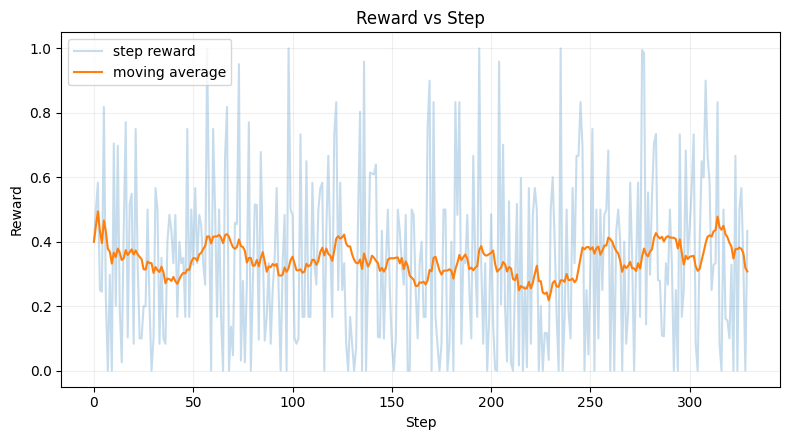

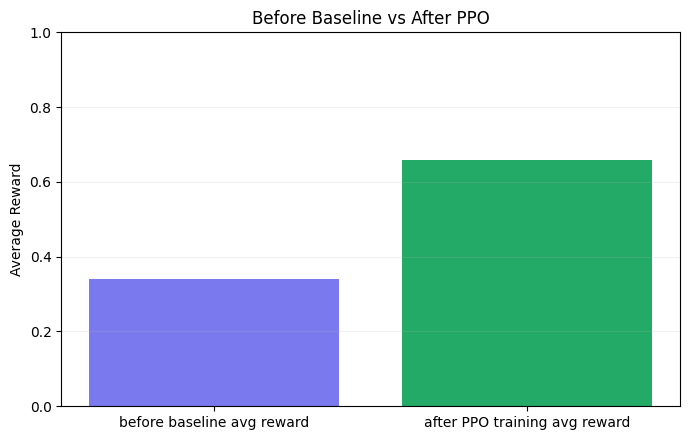

Displayed two plots, saved training_logs.json, and updated version metadata for automatic inference loading.


In [4]:
from collections import Counter

rewards = [float(x['reward']) for x in trajectories]
if len(rewards) == 0:
    raise ValueError('No rewards found in trajectories; cannot plot Reward vs Step.')

window = 20
ma = [sum(rewards[max(0, i-window+1):i+1]) / min(window, i+1) for i in range(len(rewards))]

# Compute before/after metrics robustly.
baseline_avg = None
after_training_avg = None

try:
    from training.train_local import evaluate
    baseline_avg, _, _ = evaluate('random', episodes=24)
    after_training_avg, _, _ = evaluate('trained', episodes=24)
except Exception as exc:
    print(f'Falling back to trajectory-based before/after estimates due to: {exc}')
    baseline_avg = sum(rewards) / max(1, len(rewards))
    hr = [float(x['reward']) for x in high] if len(high) > 0 else rewards
    after_training_avg = sum(hr) / max(1, len(hr))

# Plot 1: Reward vs Step (separate output)
plt.figure(figsize=(8, 4.5))
plt.plot(rewards, alpha=0.25, label='step reward')
plt.plot(ma, label='moving average')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward vs Step')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close()

# Plot 2: Before baseline vs After PPO training (separate output)
plt.figure(figsize=(7, 4.5))
plt.bar(
    ['before baseline avg reward', 'after PPO training avg reward'],
    [baseline_avg, after_training_avg],
    color=['#7a7aee', '#22aa66']
)
plt.ylim(0, 1)
plt.ylabel('Average Reward')
plt.title('Before Baseline vs After PPO')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()
plt.close()

# Training logs required for reproducible RL pipeline.
reward_history = rewards
rolling_avg_reward = ma
action_distribution = dict(Counter([x.get('action', 'balanced') for x in trajectories]))
_counter = {'yorker': 'defensive', 'bouncer': 'balanced', 'spin': 'aggressive', 'slow_ball': 'balanced'}
align = [1.0 if _counter.get(x.get('opponent_action', 'slow_ball')) == x.get('action') else 0.0 for x in trajectories]
belief_action_alignment = sum(align) / max(1, len(align))

training_logs = {
    'reward_history': reward_history,
    'avg_reward': rolling_avg_reward,
    'action_distribution': action_distribution,
    'belief_action_alignment': belief_action_alignment,
}
with open('training/artifacts/training_logs.json', 'w') as f:
    json.dump(training_logs, f, indent=2)

# Update latest version metadata with evaluation outcomes.
if os.path.exists('trained_models'):
    versions = sorted([p for p in os.listdir('trained_models') if p.startswith('model_v')])
    if len(versions) > 0:
        latest = os.path.join('trained_models', versions[-1], 'metadata.json')
        if os.path.exists(latest):
            with open(latest, 'r') as f:
                meta = json.load(f)
        else:
            meta = {}
        meta.update({'avg_reward': float(after_training_avg), 'episodes': 24})
        with open(latest, 'w') as f:
            json.dump(meta, f, indent=2)

with open('training/artifacts/notebook_summary.json', 'w') as f:
    json.dump(
        {
            'dataset_size': len(dataset),
            'filtered_samples': len(high),
            'model': model_name,
            'before_baseline_avg_reward': baseline_avg,
            'after_ppo_training_avg_reward': after_training_avg,
            'improvement': after_training_avg - baseline_avg,
            'belief_action_alignment': belief_action_alignment,
        },
        f,
        indent=2,
    )

print('Displayed two plots, saved training_logs.json, and updated version metadata for automatic inference loading.')